In [2]:
import re
import requests
import string
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from collections import Counter, defaultdict
from transformers import GPT2Model, GPT2Tokenizer, BertTokenizer, BertModel

In [5]:
gpt2 = GPT2Model.from_pretrained("gpt2")
tokenizer_gpt2 = GPT2Tokenizer.from_pretrained("gpt2")
gpt2_wte = gpt2.wte.weight.detach().numpy()

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

[  5.9998  -8.8494   4.0655  10.2321   2.3558  -3.7626  -7.1069 -12.8809
  -1.919   -4.3026]
-6.9082 6


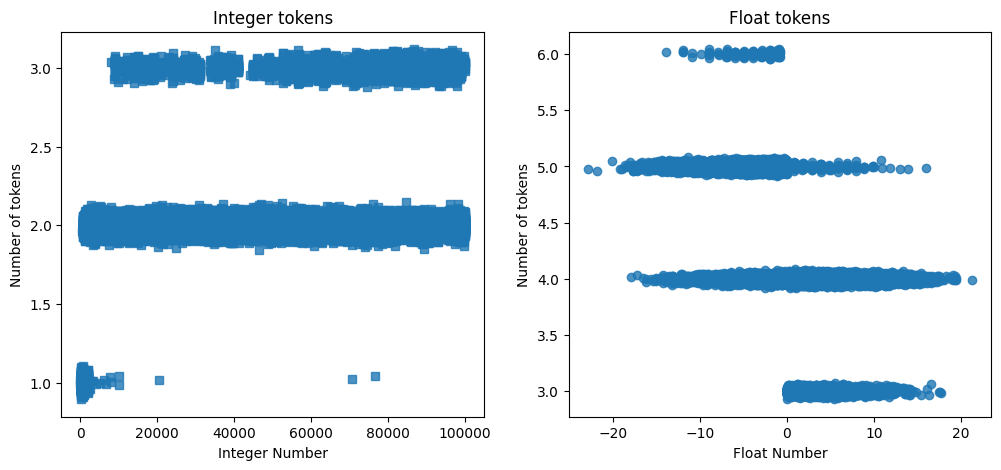

In [ ]:
numbers = 99_999 # = 99999
int_number_tokens = np.zeros(numbers, dtype=int)
float_number_tokens = np.zeros(numbers, dtype=int)

# random float numbers
float_random_numbers = (5*np.random.randn(numbers)).round(4) # round to 4 decimals so it has 5 digits
print(float_random_numbers[:10])

for i in range(numbers):
    int_number_tokens[i] = len(tokenizer_gpt2.encode(str(i)))
    float_number_tokens[i] = len(tokenizer_gpt2.encode(str(float_random_numbers[i])))

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(int_number_tokens+np.random.randn(numbers)/30, "s", label="Integer tokens", alpha=0.8)
ax[0].set_title("Integer tokens")
ax[0].set_xlabel("Integer Number")
ax[0].set_ylabel("Number of tokens")
ax[1].plot(float_random_numbers, float_number_tokens+np.random.randn(numbers)/50, "o", label="Float tokens", alpha=0.8)
ax[1].set_title("Float tokens")
ax[1].set_xlabel("Float Number")
ax[1].set_ylabel("Number of tokens")

# we can see that high integer numbers require between 2 and 3 tokens, while float numbers require between 3 and 6 tokens independently of their value.
# This is because the tokenizer splits the float numbers into multiple tokens, while it can represent high integer numbers with fewer tokens.
# The floats numbers also have negative character and dot character, which increases the number of tokens required to represent them.

In [31]:
# print a float number with 5 tokens
for i in range(numbers):
    if float_number_tokens[i] == 6:
        float_number = float_random_numbers[i]
        print("Float number", float_random_numbers[i], "has", float_number_tokens[i], "tokens")
        break

# reconstruct the float number from its tokens
for token in tokenizer_gpt2.encode(str(float_number)):
    print(tokenizer_gpt2.decode([token]))

Float number -6.9082 has 6 tokens
-
6
.
9
08
2


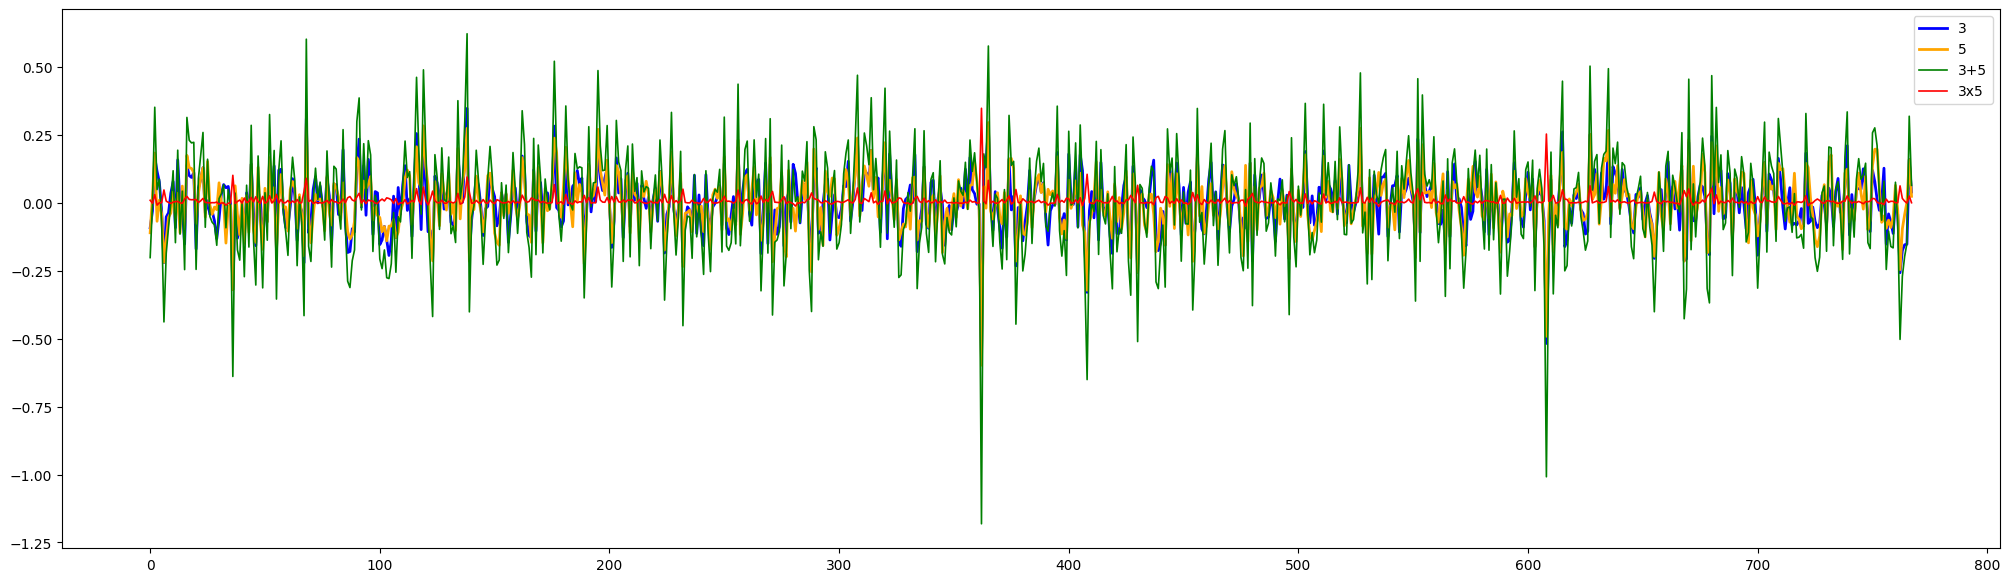

In [63]:
# are these embeddings related
eq1 = "3"
eq2 = "5"

tokens_eq1 = tokenizer_gpt2.encode(eq1)
tokens_eq2 = tokenizer_gpt2.encode(eq2)

emb1 = gpt2_wte[tokens_eq1][0]
emb2 = gpt2_wte[tokens_eq2][0]
emb3 = emb1 + emb2
emb4 = emb1 * emb2

plt.figure(figsize=(25, 7))
plt.plot(emb1, label="3", color="blue", linewidth=2)
plt.plot(emb2, label="5", color="orange", linewidth=2)
plt.plot(emb3, label="3+5", color="green", linewidth=1.2)
plt.plot(emb4, label="3x5", color="red", linewidth=1.2)
plt.legend()
plt.show()

In [ ]:
# what if we unembedd the sum and product of the embeddings
# this is the dot product of the embedding with the transpose of the embedding matrix, which gives us a vector of logits for each token in the vocabulary
unemb3 = emb3 @ gpt2_wte.T # (768,) x (768, 50257) -> 50257
unemb4 = emb4 @ gpt2_wte.T # (768,) x (768, 50257) -> 50257

# now we can decode the logits to get the most likely token
token_unemb3 = np.argmax(unemb3)
token_unemb4 = np.argmax(unemb4)

print("Most likely token for 3+5:", tokenizer_gpt2.decode([token_unemb3]))
print("Most likely token for 3x5:", tokenizer_gpt2.decode([token_unemb4]))

Most likely token for 3+5: 5
Most likely token for 3x5:  Weinstein


In [ ]:
# As a conclusion, token math makes no sense since they are completely unrelated to the actual meaning of the tokens
# Embedding vectors, however, can be manipulated matehmatically, but the result of these manipulations does not have any meaning in the token space, since the tokens are discrete and the embeddings are continuous.
# For that reason, it is better to ask an LLM to perform mathematical operations through coding, rather than trying to manipulate the embeddings directly, since it doesnt have the capacity to do it by itself.